# Actinver — US Equity Dividend Strategy
**Centro de control mensual** · Corre celda por celda para analizar el último run o ejecutar el pipeline completo.

In [1]:
# ============================================================
# CELDA 1 — [PARAMS]  Única celda a modificar en uso normal
# ============================================================

# Modo de ejecución
RUN_MODE = "backtest"   # "backtest" | "live"

# Período
BACKTEST_START = "2016-01-01"
BACKTEST_END   = None          # None = hasta hoy

# --- Restricciones del portafolio (QP) ---
MIN_PORTFOLIO_YIELD = 0.03
MAX_WEIGHT          = 0.05
RISK_AVERSION       = 1.0      # γ en la función objetivo

# --- Filtros del universo ---
MIN_MKTCAP       = 100e9
MIN_YIELD_SCREEN = 0.005
MIN_ADV          = 50e6

# --- Protocolo de infeasibility ---
INFEASIBILITY_MODE  = False
RELAXED_YIELD       = 0.025
RELAXED_MAX_WEIGHT  = 0.10

# --- Black-Litterman ---
TAU             = 0.05
LOOKBACK_MONTHS = 36
MIN_OBS_MONTHS  = 24

# --- Stop-loss / Take-profit ---
EWMA_SPAN    = 12
SL_THRESHOLD = 1.0
TP_THRESHOLD = 1.0

print(f"RUN_MODE: {RUN_MODE}  |  {BACKTEST_START} → {BACKTEST_END or 'hoy'}")
print(f"Yield mínimo: {MIN_PORTFOLIO_YIELD:.1%}  |  Peso máx: {MAX_WEIGHT:.0%}  |  γ: {RISK_AVERSION}")

RUN_MODE: backtest  |  2016-01-01 → hoy
Yield mínimo: 3.0%  |  Peso máx: 5%  |  γ: 1.0


In [2]:
# ============================================================
# CELDA 2 — Imports
# ============================================================
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display
warnings.filterwarnings("ignore")

import main
from main import (
    ROOT, DATA_RAW, DATA_PROCESSED,
    read_last_run, run_universe, run_features, run_optimizer,
    run_signals, run_backtest, diagnose_infeasibility,
    run_walk_forward, export_excel, build_metrics_table,
)

plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})
print("Módulos cargados  ✓")

Módulos cargados  ✓


In [3]:
# ============================================================
# CELDA 3 — Último run ejecutado
# ============================================================
last = read_last_run()
if last:
    p   = last["params"]
    out = last.get("outputs", {})
    print(f"Último pipeline:  {last['run_date']}  |  modo={last['run_mode']}  |  outcome={last['outcome']}")
    print(f"Parámetros:       yield_min={p['min_portfolio_yield']:.1%}  max_w={p['max_weight']:.0%}  γ={p['risk_aversion']}")
    if out:
        feas = out.get("optimizer_feasible")
        y    = out.get("portfolio_yield")
        n    = out.get("portfolio_n_stocks")
        print(f"Portafolio:       {'factible' if feas else 'INFEASIBLE'}" + (f"  yield={y:.2%}  n={n}" if feas and y else ""))
    print("\nContinúa si los datos están actualizados, o ejecuta: !python main.py")
else:
    print("Sin run previo. Ejecuta: !python main.py  o corre las celdas del pipeline.")

Sin run previo. Ejecuta: !python main.py  o corre las celdas del pipeline.


In [4]:
# ============================================================
# CELDA 4 — Universo elegible
# ============================================================
if RUN_MODE == "live":
    universe_df = run_universe(MIN_MKTCAP, MIN_YIELD_SCREEN, MIN_ADV)
else:
    csvs = sorted(DATA_RAW.glob("universe_*.csv"))
    universe_df = pd.read_csv(csvs[-1]) if csvs else run_universe(MIN_MKTCAP, MIN_YIELD_SCREEN, MIN_ADV)
    print(f"Universo: {csvs[-1].name if csvs else 'recién calculado'}")

print(f"{len(universe_df)} acciones  |  mktcap mediana: ${universe_df['market_cap'].median()/1e9:.0f}B  |  yield avg: {universe_df['dividend_yield'].mean():.2%}")
display(
    universe_df.style
    .format({"market_cap": "${:,.0f}", "dividend_yield": "{:.2%}", "adv_90d": "${:,.0f}", "price": "${:.2f}"})
    .background_gradient(subset=["dividend_yield"], cmap="YlGn")
    .background_gradient(subset=["market_cap"], cmap="Blues")
    .set_caption(f"Universo elegible — {pd.Timestamp.today().strftime('%Y-%m-%d')}")
)

Universo: universe_20260601.csv
76 acciones  |  mktcap mediana: $178B  |  yield avg: 2.16%


,ticker,market_cap,dividend_yield,adv_90d,history_start,price
0,MSFT,"$3,415,074,368,081",0.77%,"$15,115,610,727",2013-01-02,$459.73
1,AVGO,"$2,184,859,939,731",0.54%,"$8,536,276,248",2013-01-02,$461.46
2,LLY,"$962,376,207,936",0.60%,"$3,151,745,005",2013-01-02,$1079.21
3,WMT,"$907,138,577,992",0.85%,"$2,685,284,546",2013-01-02,$113.81
4,JPM,"$793,992,843,007",1.99%,"$2,910,945,124",2013-01-02,$296.32
5,ORCL,"$703,710,914,215",0.82%,"$4,556,028,587",2013-01-02,$244.68
6,XOM,"$618,467,593,871",2.73%,"$3,186,875,897",2013-01-02,$149.21
7,V,"$607,017,608,165",0.81%,"$2,419,456,881",2013-01-02,$319.19
8,JNJ,"$535,533,562,477",2.36%,"$1,903,937,967",2013-01-02,$222.47
9,CSCO,"$473,878,703,004",1.37%,"$2,121,363,971",2013-01-02,$120.23


Features: features_2026_06.parquet


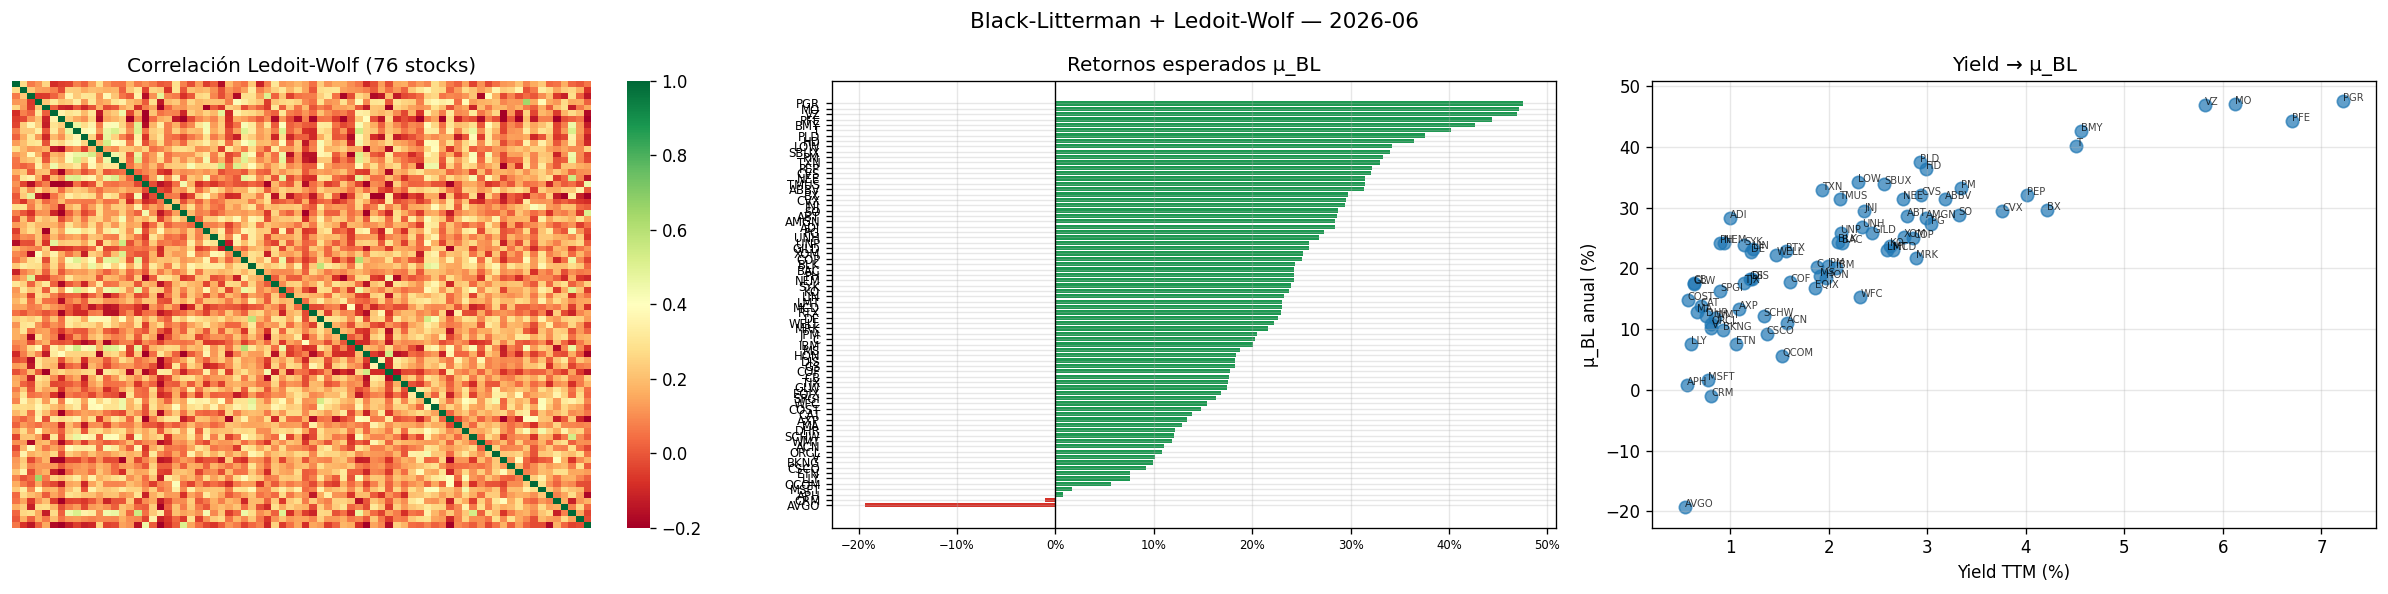

In [6]:
# ============================================================
# CELDA 5 — Features: Black-Litterman + Ledoit-Wolf
# ============================================================
if RUN_MODE == "live":
    rebalance_dt = pd.Timestamp.today().normalize() + pd.offsets.MonthEnd(0)
    features_df, cov_df = run_features(rebalance_dt, universe_df, LOOKBACK_MONTHS, MIN_OBS_MONTHS, RISK_AVERSION, TAU)
else:
    feat_files = sorted(DATA_PROCESSED.glob("features_*.parquet"))
    cov_files  = sorted(DATA_PROCESSED.glob("cov_*.parquet"))
    if not feat_files:
        raise FileNotFoundError("No hay features guardadas — ejecuta python main.py primero.")
    features_df = pd.read_parquet(feat_files[-1])
    cov_df      = pd.read_parquet(cov_files[-1])
    stem = cov_files[-1].stem.split("_")
    rebalance_dt = pd.Timestamp(f"{stem[1]}-{stem[2]}-01") + pd.offsets.MonthEnd(0)
    print(f"Features: {feat_files[-1].name}")

# ── Plots ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle(f"Black-Litterman + Ledoit-Wolf — {rebalance_dt.strftime('%Y-%m')}", fontsize=13)

S, sd = cov_df.values, np.sqrt(np.diag(cov_df.values))
sns.heatmap(pd.DataFrame(S / np.outer(sd, sd), index=cov_df.index, columns=cov_df.columns),
            ax=axes[0], cmap="RdYlGn", vmin=-0.2, vmax=1, xticklabels=False, yticklabels=False)
axes[0].set_title(f"Correlación Ledoit-Wolf ({len(cov_df)} stocks)")

fs = features_df.sort_values("mu_bl")
axes[1].barh(fs["ticker"], fs["mu_bl"] * 12, color=["#d73027" if v < 0 else "#1a9850" for v in fs["mu_bl"]])
axes[1].axvline(0, color="black", lw=0.8)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axes[1].set_title("Retornos esperados μ_BL"); axes[1].tick_params(labelsize=7)

axes[2].scatter(features_df["dividend_yield_ttm"] * 100, features_df["mu_bl"] * 12 * 100, alpha=0.7, s=55)
for _, r in features_df.iterrows():
    axes[2].annotate(r["ticker"], (r["dividend_yield_ttm"] * 100, r["mu_bl"] * 12 * 100), fontsize=6, alpha=0.75)
axes[2].set_xlabel("Yield TTM (%)"); axes[2].set_ylabel("μ_BL anual (%)"); axes[2].set_title("Yield → μ_BL")
plt.tight_layout(); plt.show()

17:33:57  INFO      optimize_portfolio | 2026-06 | n=76 | γ=1.0 | min_yield=3.0% | max_w=5.0%
17:33:57  INFO        QP resuelto ✓  yield=3.82%  σ_anual=11.78%  μ_BL_anual=36.22%  n_activos=20
17:33:57  INFO      Guardado → /home/agayon/repos_gayummy/actinver/dividend-investment-stgy/data/processed/weights_2026_06.parquet


Portafolio — 2026-06  |  yield: 3.82%  |  vol: 11.78%  |  n: 20


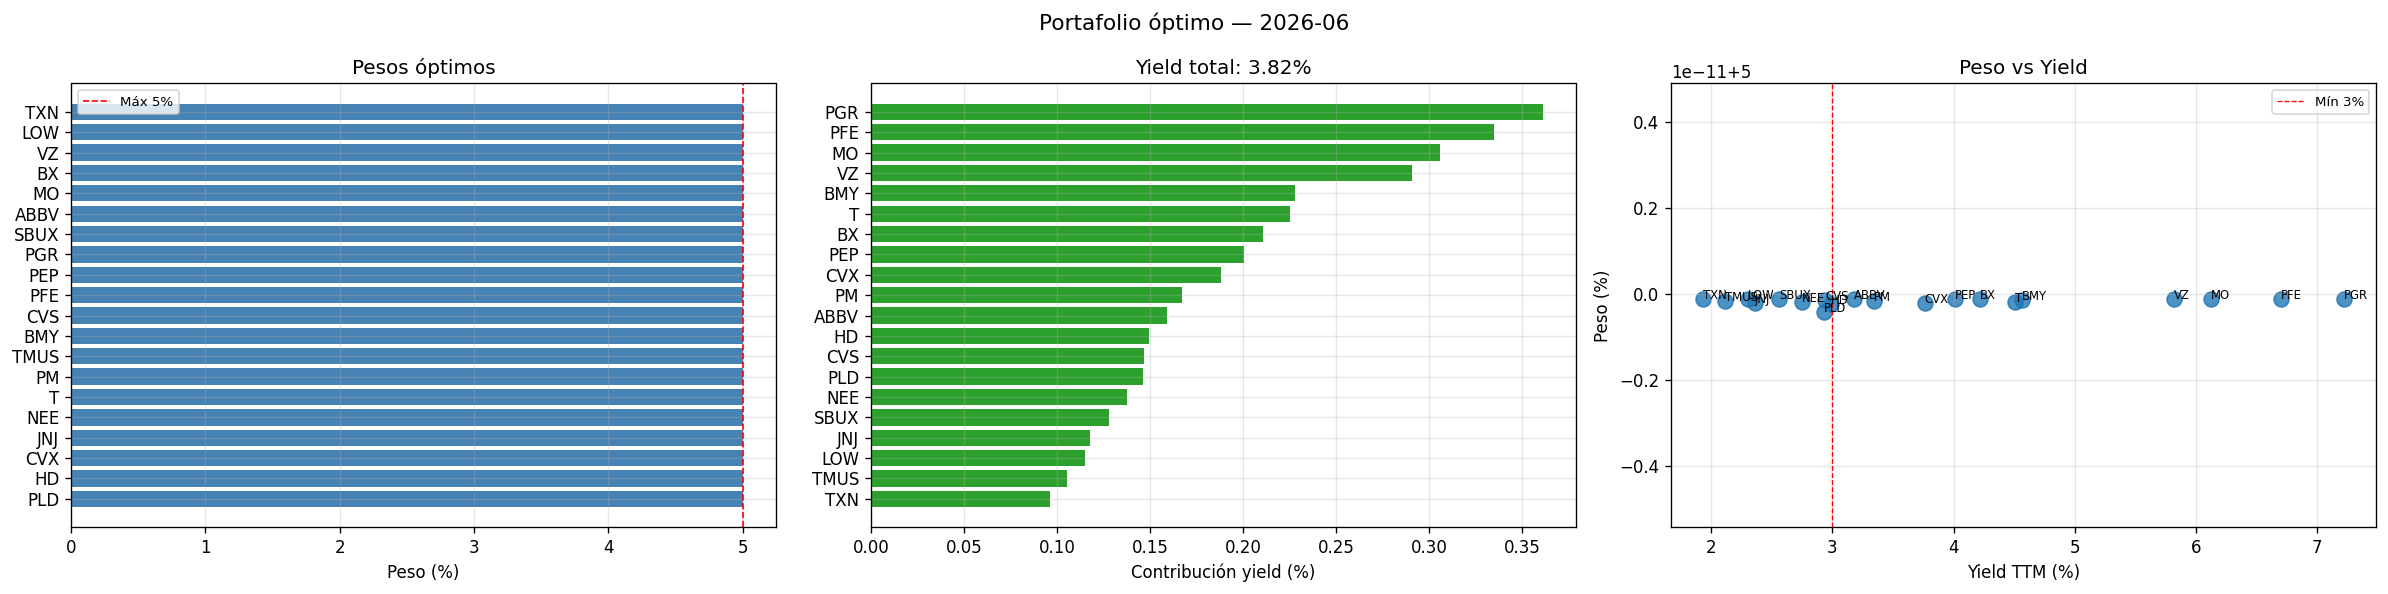

,ticker,weight,expected_return,contribution_yield
0,ABBV,5.00%,2.615%,0.1590%
1,MO,5.00%,3.928%,0.3060%
2,LOW,5.00%,2.849%,0.1150%
3,TXN,5.00%,2.748%,0.0965%
4,PEP,5.00%,2.677%,0.2005%
5,PFE,5.00%,3.698%,0.3350%
6,SBUX,5.00%,2.831%,0.1280%
7,PGR,5.00%,3.961%,0.3610%
8,VZ,5.00%,3.912%,0.2910%
9,BX,5.00%,2.474%,0.2110%


In [7]:
# ============================================================
# CELDA 6 — Optimización QP
# ============================================================
weights_df = run_optimizer(features_df, cov_df, RISK_AVERSION, MIN_PORTFOLIO_YIELD, MAX_WEIGHT, rebalance_dt)

if weights_df is not None:
    weights_df = weights_df[weights_df["weight"] > 1e-4].copy()
    port_yield = weights_df["contribution_yield"].sum()
    S_a        = cov_df.loc[weights_df["ticker"], weights_df["ticker"]].values
    port_vol   = np.sqrt(weights_df["weight"].values @ S_a @ weights_df["weight"].values * 12)
    print(f"Portafolio — {rebalance_dt.strftime('%Y-%m')}  |  yield: {port_yield:.2%}  |  vol: {port_vol:.2%}  |  n: {len(weights_df)}")

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f"Portafolio óptimo — {rebalance_dt.strftime('%Y-%m')}", fontsize=13)

    w0 = weights_df.sort_values("weight")
    axes[0].barh(w0["ticker"], w0["weight"] * 100, color="steelblue")
    axes[0].axvline(MAX_WEIGHT * 100, color="red", lw=1, ls="--", label=f"Máx {MAX_WEIGHT:.0%}")
    axes[0].set_xlabel("Peso (%)"); axes[0].set_title("Pesos óptimos"); axes[0].legend(fontsize=8)

    w1 = weights_df.sort_values("contribution_yield")
    axes[1].barh(w1["ticker"], w1["contribution_yield"] * 100, color="#2ca02c")
    axes[1].set_xlabel("Contribución yield (%)"); axes[1].set_title(f"Yield total: {port_yield:.2%}")

    axes[2].scatter(weights_df["contribution_yield"] * 100 / weights_df["weight"], weights_df["weight"] * 100, s=80, alpha=0.8)
    for _, r in weights_df.iterrows():
        axes[2].annotate(r["ticker"], (r["contribution_yield"] * 100 / r["weight"], r["weight"] * 100), fontsize=7)
    axes[2].axvline(MIN_PORTFOLIO_YIELD * 100, color="red", lw=0.8, ls="--", label=f"Mín {MIN_PORTFOLIO_YIELD:.0%}")
    axes[2].set_xlabel("Yield TTM (%)"); axes[2].set_ylabel("Peso (%)"); axes[2].set_title("Peso vs Yield"); axes[2].legend(fontsize=8)
    plt.tight_layout(); plt.show()

    display(
        weights_df[["ticker", "weight", "expected_return", "contribution_yield"]].style
        .format({"weight": "{:.2%}", "expected_return": "{:.3%}", "contribution_yield": "{:.4%}"})
        .background_gradient(subset=["weight"], cmap="Blues")
        .background_gradient(subset=["contribution_yield"], cmap="YlGn")
        .set_caption(f"Pesos óptimos — yield portafolio: {port_yield:.2%}")
    )
else:
    print("QP infeasible con los parámetros actuales. Continúa a la celda de diagnóstico (Celda 7).")

In [8]:
# ============================================================
# CELDA 7 — Diagnóstico de infeasibility
# Solo tiene efecto si weights_df es None o INFEASIBILITY_MODE=True
# ============================================================
if weights_df is None or INFEASIBILITY_MODE:
    diag = diagnose_infeasibility(
        features_df, cov_df, rebalance_dt,
        params=dict(
            min_yield=MIN_PORTFOLIO_YIELD, max_weight=MAX_WEIGHT, gamma=RISK_AVERSION,
            relaxed_yield=RELAXED_YIELD, relaxed_max_weight=RELAXED_MAX_WEIGHT,
        ),
    )
    print(f"Yield máximo alcanzable (sin constraint): {diag['max_achievable_yield']:.2%}")
    print(f"N° stocks elegibles:                      {diag['n_eligible']}")
    print()
    descs = {
        "A": f"Relajar yield objetivo → {RELAXED_YIELD:.1%}",
        "B": f"Relajar peso máximo → {RELAXED_MAX_WEIGHT:.0%}",
        "C": "Sin constraint de yield (escenario base)",
        "D": "Mantener portafolio anterior (sin rebalanceo)",
    }
    for key, sc in diag["scenarios"].items():
        if sc is None:
            print(f"  Escenario {key} — {descs[key]:<45} → mantener posición")
        elif sc["feasible"]:
            print(f"  Escenario {key} — {descs[key]:<45} → factible   yield={sc['yield']:.2%}  n={sc['n_stocks']}")
        else:
            print(f"  Escenario {key} — {descs[key]:<45} → infactible")
    print()
    print("Ajusta RELAXED_YIELD / RELAXED_MAX_WEIGHT en [PARAMS] (Celda 1) y corre Celda 8.")
else:
    print("Sin infeasibility — celda sin efecto.")

Sin infeasibility — celda sin efecto.


In [9]:
# ============================================================
# CELDA 8 — Ajuste de infeasibility (acción)
# Elige el escenario modificando los parámetros abajo y re-corre esta celda.
# ============================================================
if weights_df is None or INFEASIBILITY_MODE:
    # ── Selección de escenario ─────────────────────────────────────────────
    # Escenario A → usar RELAXED_YIELD con MAX_WEIGHT
    # Escenario B → usar MIN_PORTFOLIO_YIELD con RELAXED_MAX_WEIGHT
    # Escenario C → sin constraint de yield (min_yield=0)
    # Escenario D → dejar weights_df = None (mantener portafolio previo)

    CHOSEN_YIELD      = RELAXED_YIELD       # ← ajusta aquí
    CHOSEN_MAX_WEIGHT = MAX_WEIGHT          # ← ajusta aquí

    weights_df = run_optimizer(
        features_df, cov_df, RISK_AVERSION,
        CHOSEN_YIELD, CHOSEN_MAX_WEIGHT,
        rebalance_dt, save=False,
    )
    if weights_df is not None:
        weights_df = weights_df[weights_df["weight"] > 1e-4].copy()
        print(f"Portafolio ajustado — yield: {weights_df['contribution_yield'].sum():.2%}  n: {len(weights_df)}")
        display(
            weights_df[["ticker", "weight", "contribution_yield"]].style
            .format({"weight": "{:.2%}", "contribution_yield": "{:.4%}"})
            .background_gradient(subset=["weight"], cmap="Blues")
        )
    else:
        print("Escenario D — se mantiene el portafolio del mes anterior (sin rebalanceo).")
else:
    print("Sin infeasibility — celda sin efecto.")

Sin infeasibility — celda sin efecto.


In [10]:
# ============================================================
# CELDA 9 — Señales stop-loss / take-profit
# ============================================================
sig_files = sorted(DATA_PROCESSED.glob("signals_*.parquet"))
if sig_files and RUN_MODE != "live":
    signals_df = pd.read_parquet(sig_files[-1])
    print(f"Señales cargadas: {sig_files[-1].name}")
elif weights_df is not None:
    import yfinance as yf
    tks    = weights_df["ticker"].tolist()
    raw_p  = yf.download(tks, period="2d", auto_adjust=True, progress=False)
    prices = raw_p["Close"].iloc[-1] if isinstance(raw_p["Close"], pd.DataFrame) else raw_p["Close"]
    pos_df = pd.DataFrame([{"ticker": tk, "entry_date": rebalance_dt,
                             "entry_price": float(prices.get(tk, 0))} for tk in tks])
    signals_df = run_signals(pos_df, rebalance_dt, SL_THRESHOLD, TP_THRESHOLD, EWMA_SPAN)
else:
    print("Sin portafolio activo — no hay señales que evaluar.")
    signals_df = pd.DataFrame()

if not signals_df.empty:
    n_hold, n_stop, n_take = [(signals_df["signal"] == v).sum() for v in ("hold", "stop", "take")]
    print(f"HOLD: {n_hold}   STOP-LOSS: {n_stop}   TAKE-PROFIT: {n_take}")
    _sig_color = lambda v: {"hold": "background-color:#f0f0f0",
                             "stop": "background-color:#ffcccc",
                             "take": "background-color:#ccffcc"}.get(v, "")
    display(
        signals_df.style
        .format({"r_acum": "{:.2%}", "sigma_ewma": "{:.2%}"})
        .map(_sig_color, subset=["signal"])
        .set_caption("Señales stop-loss / take-profit")
    )

Señales cargadas: signals_2026_06.parquet
HOLD: 20   STOP-LOSS: 0   TAKE-PROFIT: 0


,ticker,entry_month,r_acum,sigma_ewma,signal
0,ABBV,2026-06,0.00%,4.85%,hold
1,MO,2026-06,0.00%,6.72%,hold
2,LOW,2026-06,0.00%,6.88%,hold
3,TXN,2026-06,0.00%,15.16%,hold
4,PEP,2026-06,0.00%,6.21%,hold
5,PFE,2026-06,0.00%,4.12%,hold
6,SBUX,2026-06,0.00%,8.95%,hold
7,PGR,2026-06,0.00%,6.31%,hold
8,VZ,2026-06,0.00%,5.27%,hold
9,BX,2026-06,0.00%,9.25%,hold


Resultados cargados: backtest_results.parquet  (125 meses)


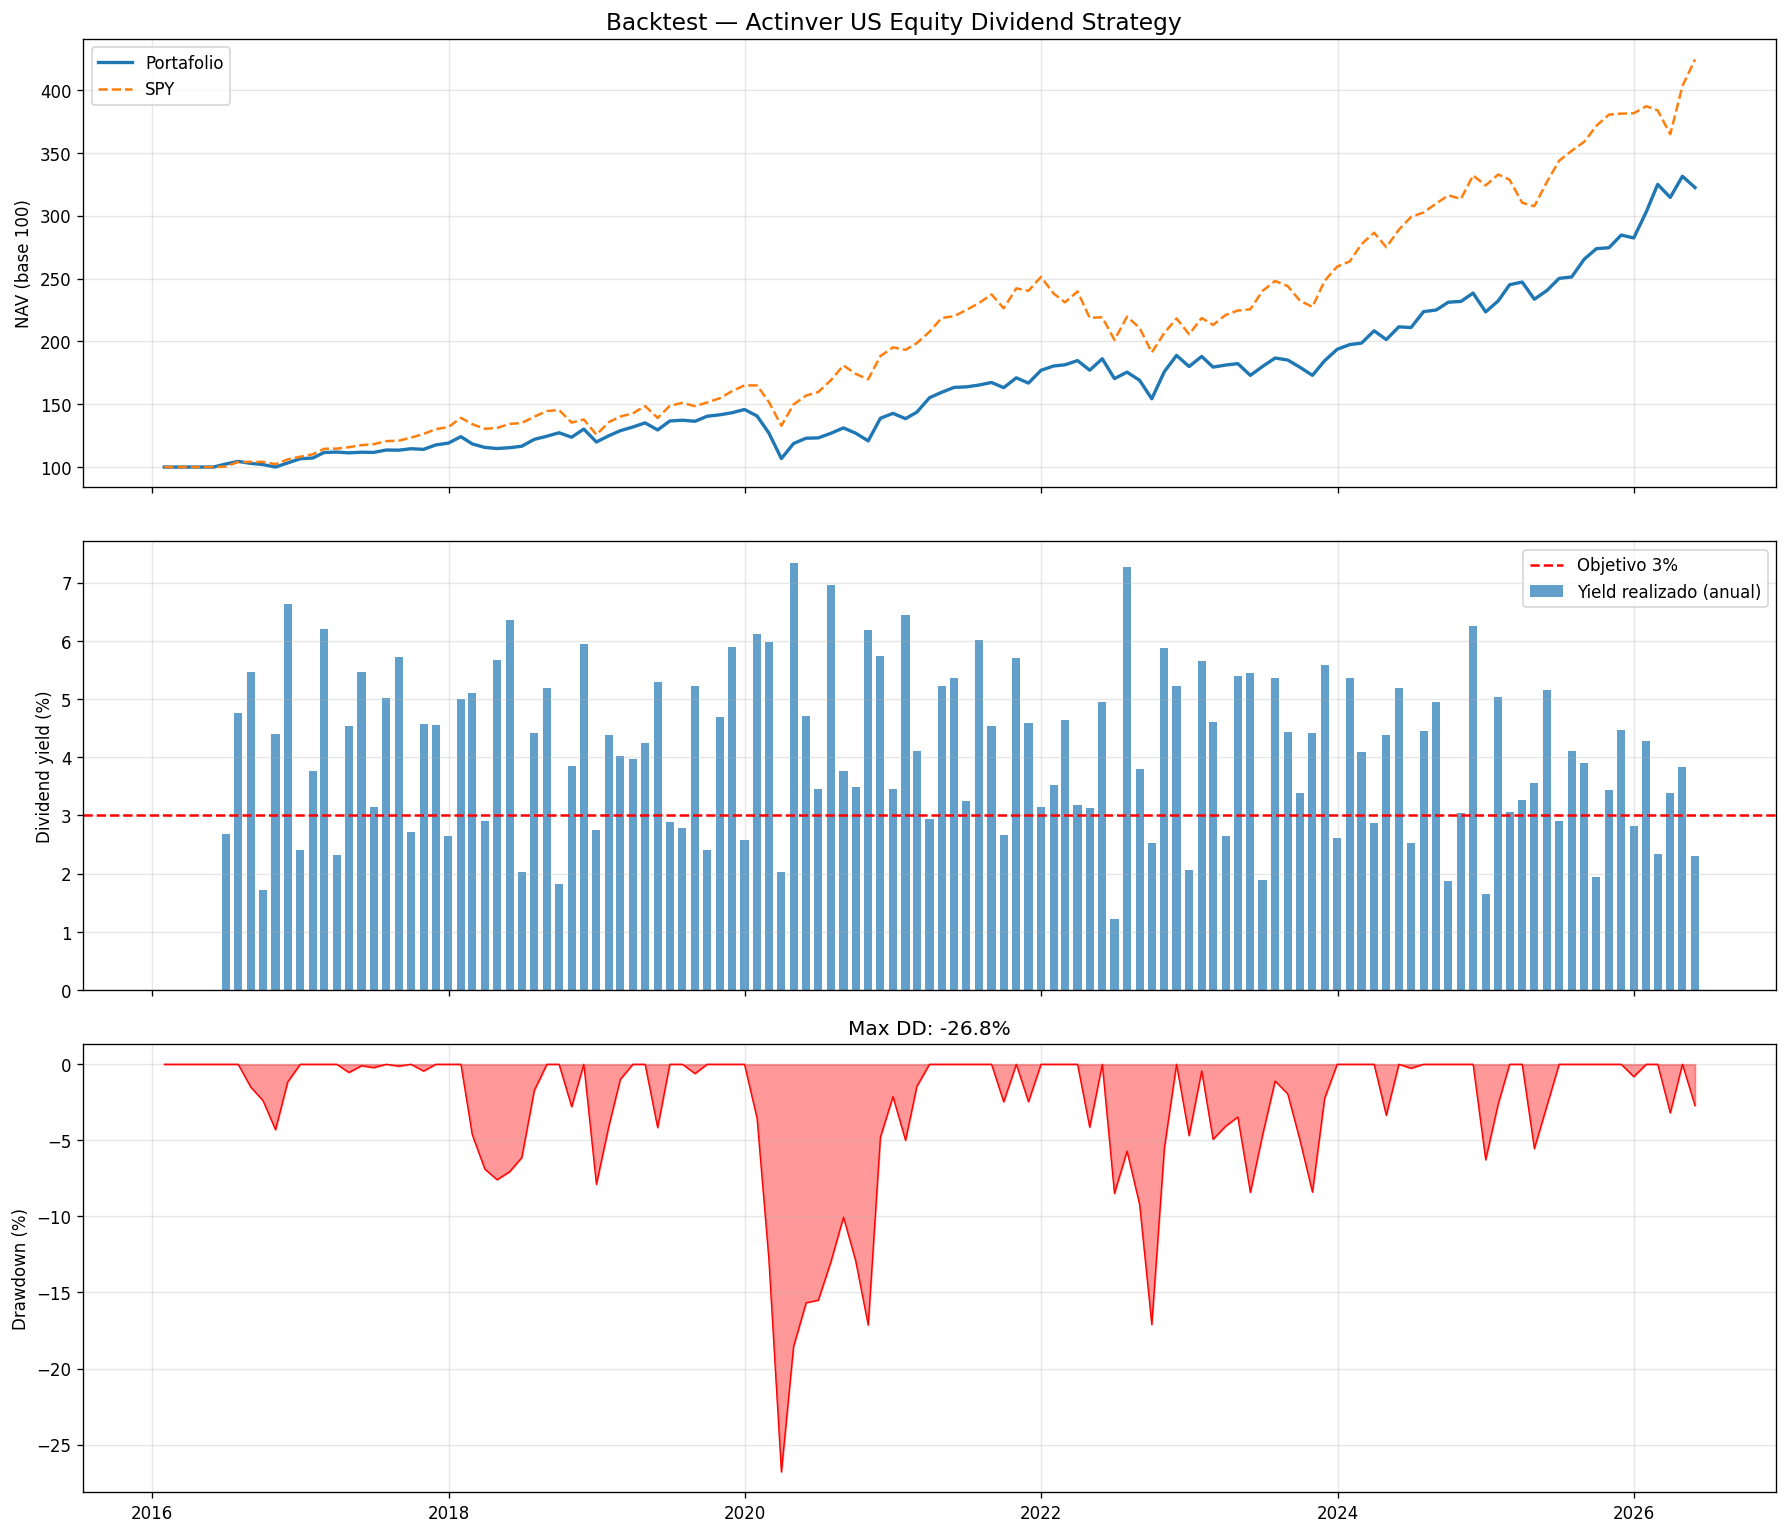

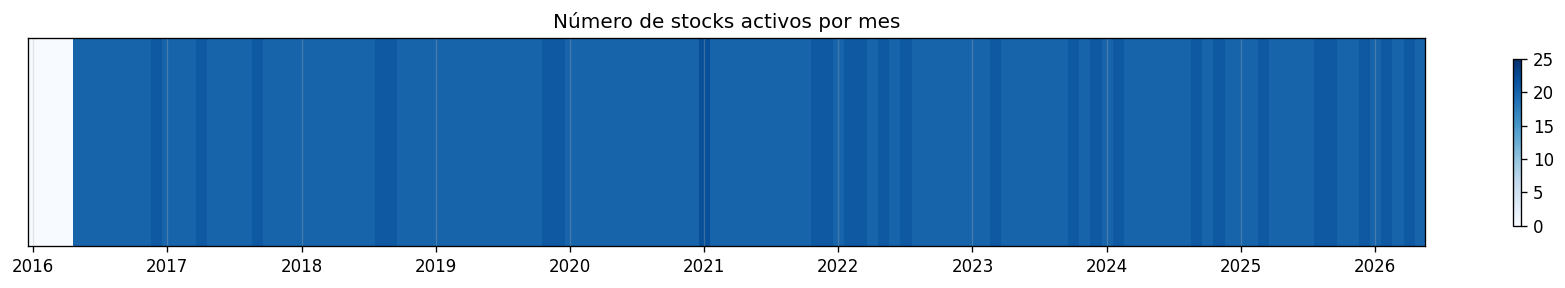

In [11]:
# ============================================================
# CELDA 10 — Backtest completo  (solo RUN_MODE == "backtest")
# ============================================================
if RUN_MODE != "backtest":
    print("Celda 10 solo ejecuta en RUN_MODE='backtest'")
else:
    res_file = DATA_PROCESSED / "backtest_results.parquet"
    if res_file.exists():
        results = pd.read_parquet(res_file)
        print(f"Resultados cargados: {res_file.name}  ({len(results)} meses)")
    else:
        print("Corriendo backtest completo (puede tardar ~15 min)...")
        results, _ = run_backtest(BACKTEST_START, BACKTEST_END, MIN_PORTFOLIO_YIELD, MAX_WEIGHT, RISK_AVERSION)

    bm_nav = 100 * (1 + results["benchmark_return"]).cumprod()
    dd     = (results["nav"] / results["nav"].cummax() - 1) * 100

    fig, axes = plt.subplots(3, 1, figsize=(15, 13), sharex=True)
    fig.suptitle("Backtest — Actinver US Equity Dividend Strategy", fontsize=14)

    axes[0].plot(results.index, results["nav"], label="Portafolio", lw=2)
    axes[0].plot(results.index, bm_nav, label="SPY", lw=1.5, ls="--")
    axes[0].set_ylabel("NAV (base 100)"); axes[0].legend()
    axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

    axes[1].bar(results.index, results["realized_yield"] * 12 * 100, width=20, alpha=0.7, label="Yield realizado (anual)")
    axes[1].axhline(MIN_PORTFOLIO_YIELD * 100, color="red", lw=1.5, ls="--", label=f"Objetivo {MIN_PORTFOLIO_YIELD:.0%}")
    axes[1].set_ylabel("Dividend yield (%)"); axes[1].legend()

    axes[2].fill_between(results.index, dd, 0, alpha=0.4, color="red")
    axes[2].plot(results.index, dd, color="red", lw=0.8)
    axes[2].set_ylabel("Drawdown (%)"); axes[2].set_title(f"Max DD: {dd.min():.1f}%")
    plt.tight_layout(); plt.show()

    fig2, ax2 = plt.subplots(figsize=(15, 2.5))
    im = ax2.imshow(results["n_stocks"].values.reshape(1, -1), aspect="auto", cmap="Blues", vmin=0, vmax=25)
    ax2.set_yticks([])
    ax2.set_xticks(range(0, len(results), 12))
    ax2.set_xticklabels([results.index[i].strftime("%Y") for i in range(0, len(results), 12)])
    ax2.set_title("Número de stocks activos por mes")
    plt.colorbar(im, ax=ax2, shrink=0.8); plt.tight_layout(); plt.show()

In [12]:
# ============================================================
# CELDA 11 — Reporte de métricas
# ============================================================
met_file = DATA_PROCESSED / "backtest_metrics.json"
if met_file.exists():
    with open(met_file) as f:
        metrics = json.load(f)
elif RUN_MODE == "backtest" and "results" in dir():
    metrics = main._b.compute_metrics(results)
else:
    raise FileNotFoundError("Corre el backtest primero (Celda 10).")

df_met = build_metrics_table(metrics, MIN_PORTFOLIO_YIELD)

def _style_header(row):
    return ["font-weight:bold; background-color:#e8e8e8"] * 3 if row["Portafolio"] == "" else [""] * 3

display(
    df_met.style
    .apply(_style_header, axis=1)
    .hide(axis="index")
    .set_caption(f"Métricas de desempeño — backtest {BACKTEST_START} → {results.index[-1].strftime('%Y-%m') if 'results' in dir() else ''}")
)

Métrica,Portafolio,Benchmark / Referencia
── RENDIMIENTO ──,,
CAGR portafolio,11.89%,14.88%
Volatilidad anualizada,15.01%,—
Sharpe Ratio,0.560,—
Sortino Ratio,0.535,—
Calmar Ratio,0.444,—
── RIESGO ──,,
Max Drawdown,-26.79%,—
VaR 95% mensual,-5.46%,—
VaR 99% mensual,-9.36%,—


17:33:57  INFO      Computando walk-forward — descargando precios...
[*********************100%***********************]  76 of 76 completed
17:34:02  INFO      Walk-forward guardado → /home/agayon/repos_gayummy/actinver/dividend-investment-stgy/data/processed/walk_forward_results.parquet


Walk-forward: 124 meses  |  MAE=0.0558  |  RMSE=0.0700  |  Hit=31.2%
Shrinkage L-W avg: 0.224  (rango: 0.153–0.325)


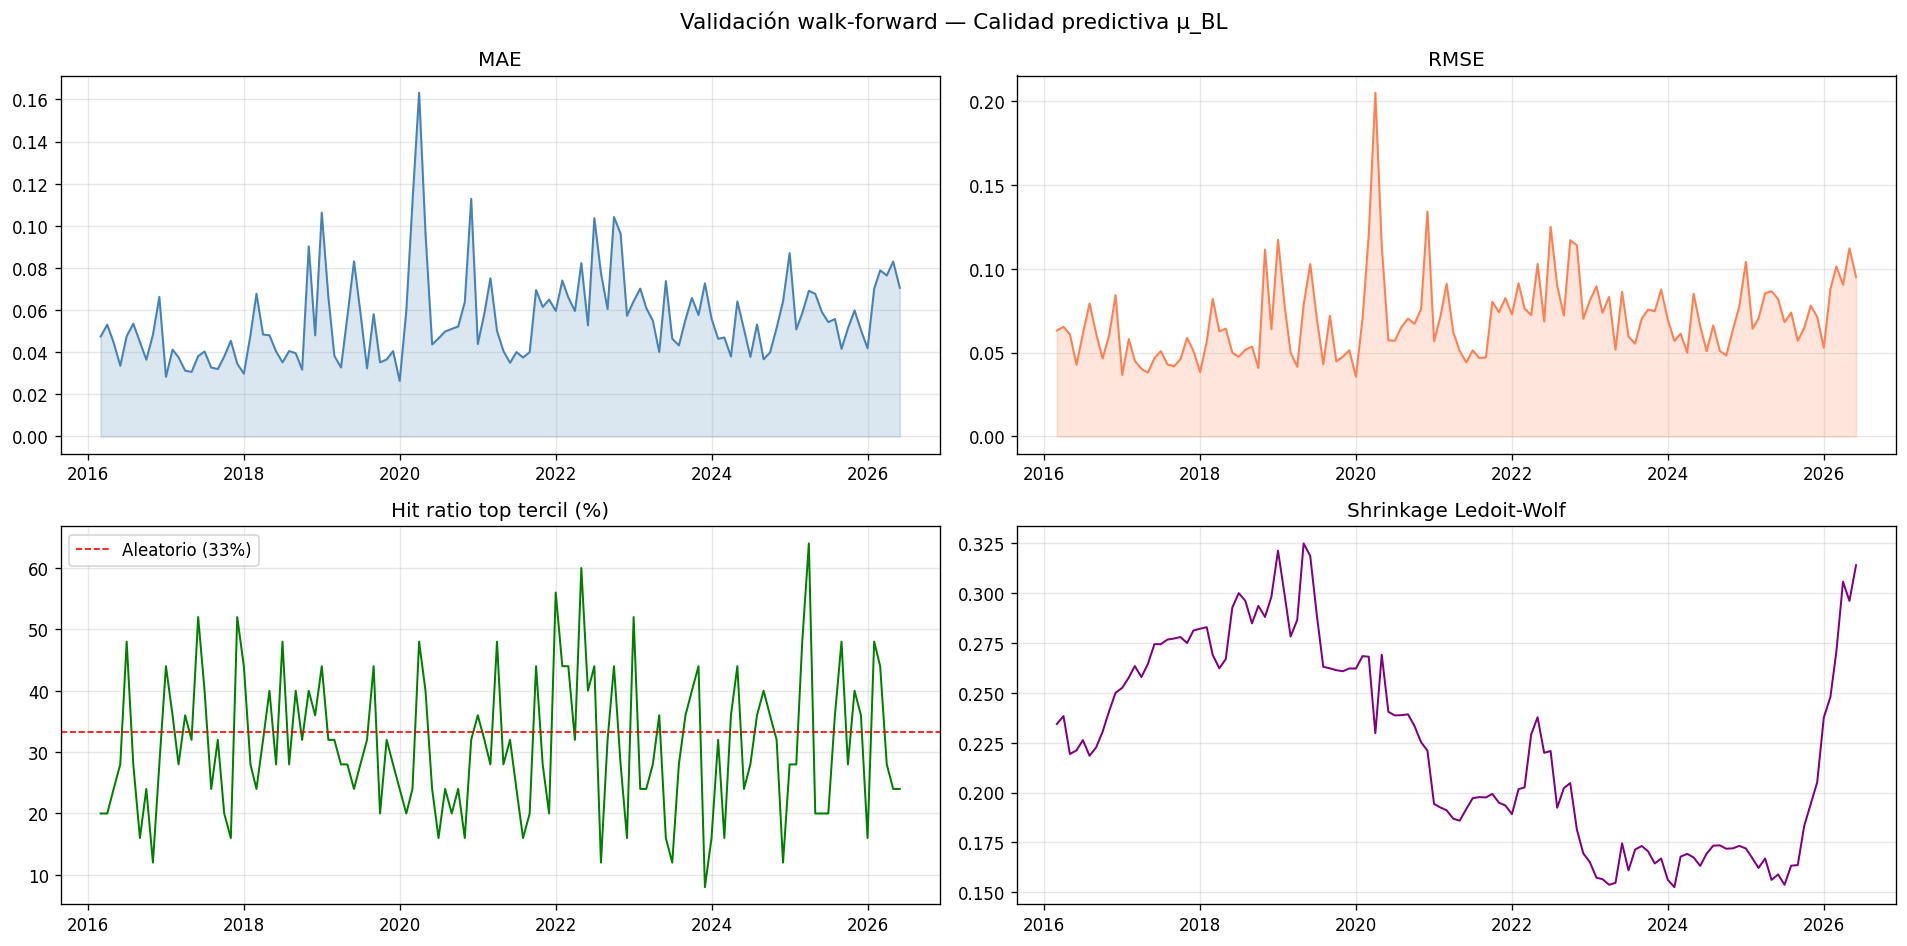

In [13]:
# ============================================================
# CELDA 12 — Validación walk-forward
# ============================================================
if RUN_MODE == "backtest" and "results" in dir():
    wf = run_walk_forward(universe_df, results, LOOKBACK_MONTHS, MIN_OBS_MONTHS, RISK_AVERSION, TAU)
    print(f"Walk-forward: {len(wf)} meses  |  MAE={wf['mae'].mean():.4f}  |  RMSE={wf['rmse'].mean():.4f}  |  Hit={wf['hit_ratio'].mean():.1%}")
    if "shrinkage" in wf.columns:
        print(f"Shrinkage L-W avg: {wf['shrinkage'].mean():.3f}  (rango: {wf['shrinkage'].min():.3f}–{wf['shrinkage'].max():.3f})")

    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    fig.suptitle("Validación walk-forward — Calidad predictiva μ_BL", fontsize=13)
    axes[0, 0].plot(wf.index, wf["mae"],  color="steelblue", lw=1.2); axes[0, 0].fill_between(wf.index, wf["mae"],  alpha=0.2, color="steelblue"); axes[0, 0].set_title("MAE")
    axes[0, 1].plot(wf.index, wf["rmse"], color="coral",    lw=1.2); axes[0, 1].fill_between(wf.index, wf["rmse"], alpha=0.2, color="coral");    axes[0, 1].set_title("RMSE")
    axes[1, 0].plot(wf.index, wf["hit_ratio"] * 100, color="green", lw=1.2)
    axes[1, 0].axhline(33.3, color="red", lw=1, ls="--", label="Aleatorio (33%)"); axes[1, 0].set_title("Hit ratio top tercil (%)"); axes[1, 0].legend()
    if "shrinkage" in wf.columns:
        axes[1, 1].plot(wf.index, wf["shrinkage"], color="purple", lw=1.2); axes[1, 1].set_title("Shrinkage Ledoit-Wolf")
    plt.tight_layout(); plt.show()
else:
    print("Corre el backtest primero (Celda 10).")

In [14]:
# ============================================================
# CELDA 13 — Exportar reporte Excel
# ============================================================
if "metrics" in dir() and "weights_df" in dir() and weights_df is not None:
    path = export_excel(
        metrics=metrics,
        weights_df=weights_df,
        results=results if "results" in dir() else None,
        wf=wf if "wf" in dir() else None,
    )
    print(f"Reporte guardado → {path}")
else:
    print("Completa el pipeline antes de exportar (necesitas metrics y weights_df).")

17:34:02  INFO      Reporte Excel guardado → /home/agayon/repos_gayummy/actinver/dividend-investment-stgy/reports/reporte_20260601.xlsx


Reporte guardado → /home/agayon/repos_gayummy/actinver/dividend-investment-stgy/reports/reporte_20260601.xlsx
